In [1]:
print("hello")

hello


In [1]:
import cv2;
import numpy as np
import matplotlib.pyplot as plt


In [2]:
image = cv2.imread("input.jpeg", cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Error: input.jpeg not found or could not be read.")
    raise FileNotFoundError("input.jpeg not found")

In [3]:
image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

In [4]:
noisy_image = image_rgb.copy()



In [5]:
noise_amount=0.5

In [6]:
num_pixels=int(noise_amount*image_rgb.shape[0]*image_rgb.shape[1])

In [7]:
for _ in range(num_pixels//2):
    x = np.random.randint(0, image_rgb.shape[0])
    y = np.random.randint(0, image_rgb.shape[1])
    noisy_image[x, y] = [255, 255, 255]


In [8]:
for _ in range(num_pixels//2):
    x = np.random.randint(0, image_rgb.shape[0])
    y = np.random.randint(0, image_rgb.shape[1])
    noisy_image[x, y] = [0, 0, 0]


In [ ]:
mean_filtered=cv2.blur(noisy_image,(5,5))
gaussian_filtered=cv2.GaussianBlur(noisy_image,(5,5),0)


In [10]:
median_filtered=cv2.medianBlur(noisy_image,5)

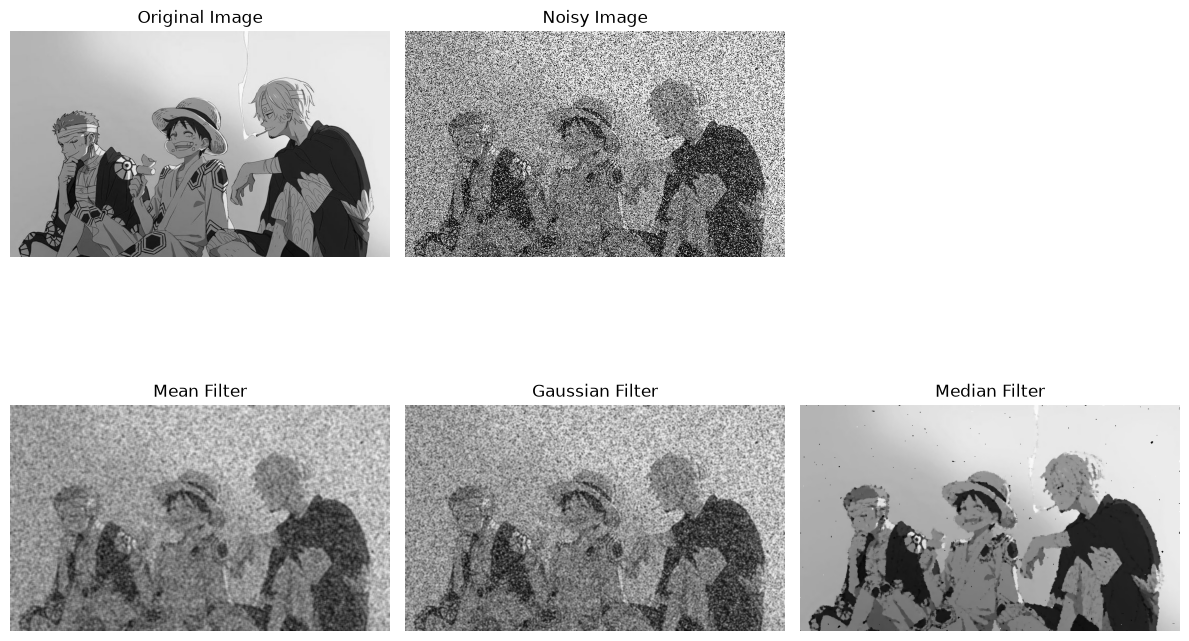

In [11]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")
plt.subplot(2, 3, 4)
plt.imshow(mean_filtered)
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(gaussian_filtered)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(median_filtered)
plt.title("Median Filter")
plt.axis("off")

plt.tight_layout()
plt.show()


In [12]:
import numpy as np

In [14]:
def calculate_mse(original,filtered):
    mse=np.mean((original.astype(float)-filtered.astype(float))**2)
    return mse

In [15]:
def calculate_psnr(original,filtered):
    mse=calculate_mse(original,filtered)
    if mse == 0:
        return float("inf")
    psnr=10*np.log10((255**2)/mse)
    return psnr



In [16]:
mse_mean = calculate_mse(image_rgb, mean_filtered)
mse_gaussian = calculate_mse(image_rgb, gaussian_filtered)
mse_median = calculate_mse(image_rgb, median_filtered)


In [17]:
psnr_mean = calculate_psnr(image_rgb, mean_filtered)
psnr_gaussian = calculate_psnr(image_rgb, gaussian_filtered)
psnr_median = calculate_psnr(image_rgb, median_filtered)



In [18]:
print("Mean Filter")
print("MSE  :", mse_mean)
print("PSNR :", psnr_mean, "dB")

print("\nGaussian Filter")
print("MSE  :", mse_gaussian)
print("PSNR :", psnr_gaussian, "dB")

print("\nMedian Filter")
print("MSE  :", mse_median)
print("PSNR :", psnr_median, "dB")


Mean Filter
MSE  : 1559.0724046140194
PSNR : 16.202140762152087 dB

Gaussian Filter
MSE  : 1743.336200750323
PSNR : 15.716992123977258 dB

Median Filter
MSE  : 356.96770809010104
PSNR : 22.604514300010578 dB
